In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.signal import argrelmax
from matplotlib.collections import LineCollection
import re  
from matplotlib.lines import Line2D
import lmfit
from scipy.optimize import curve_fit
from lmfit import Model
import os
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget
mpl.rcParams['font.family'] = 'serif'

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.signal import argrelmax
from matplotlib.collections import LineCollection
import re  
from matplotlib.lines import Line2D
import lmfit
from scipy.optimize import curve_fit
from lmfit import Model
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget
mpl.rcParams['font.family'] = 'serif'

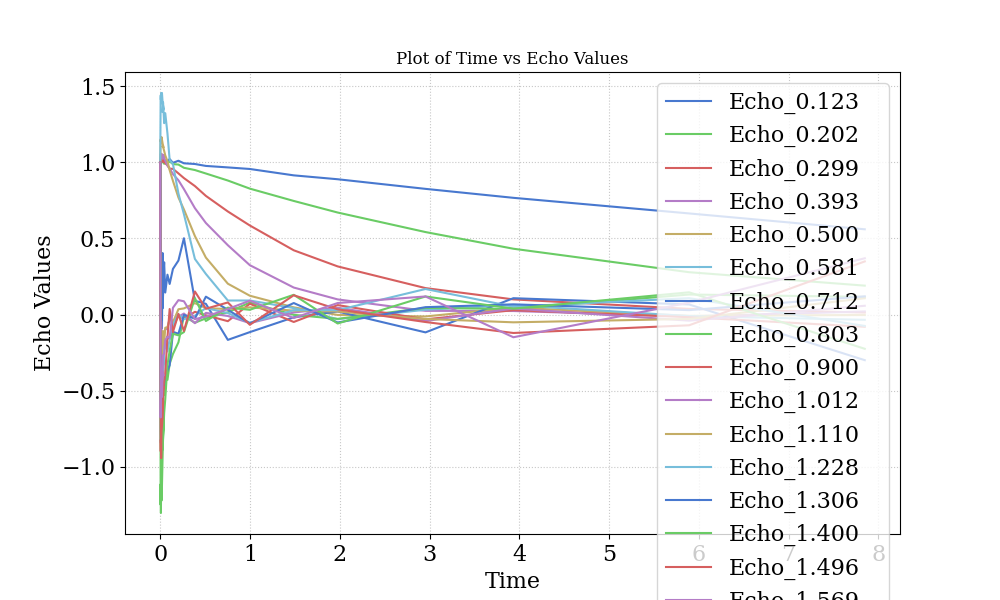

In [6]:

file_path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/MD_e_12420134.txt"
data = pd.read_csv(file_path, sep='\t', skiprows=1)


x = data.iloc[:, 0]
y_columns = data.columns[3::2]  

plt.figure(figsize=(10, 6))
for col in y_columns:
    plt.plot(x, data[col], label=col)

plt.xlabel('Time')
plt.ylabel('Echo Values')
plt.title('Plot of Time vs Echo Values')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


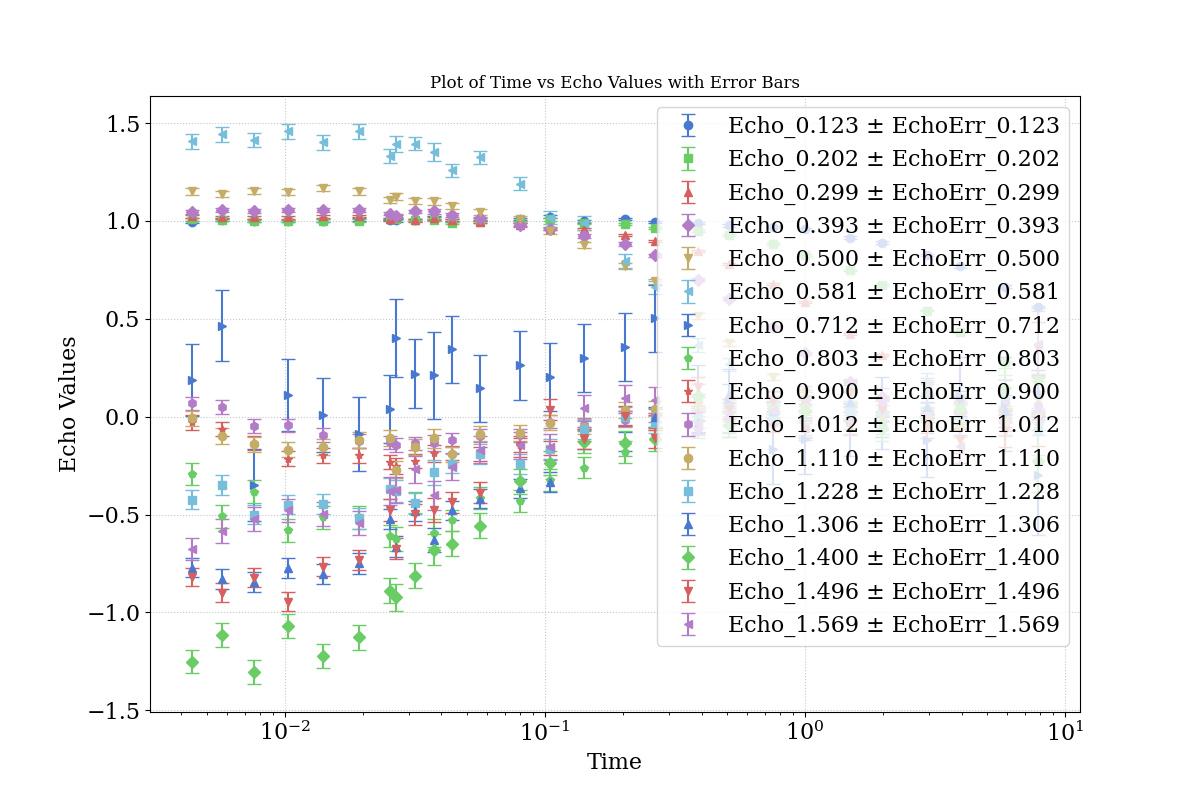

In [7]:
file_path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/MD_e_12420134.txt"
data = pd.read_csv(file_path, sep='\t', skiprows=1)


x = data.iloc[:, 0]


y_columns = data.columns[3::2] 
error_columns = data.columns[4::2]  


plt.figure(figsize=(12, 8))


markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
    marker = markers[i % len(markers)]  
    plt.errorbar(x, data[y_col], yerr=data[err_col], fmt=marker, label=f'{y_col} ± {err_col}', capsize=5, linestyle='None')


plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Echo Values')
plt.title('Plot of Time vs Echo Values with Error Bars')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [8]:
def load_diel(path, i):
    
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[2:-1]

    return df



G5P_D = [load_diel(path, i) for i in range(12420134, 12420169)]


for df in enumerate(G5P_D):
    # T = df['T'].iloc[0]
    x = df.iloc[:, 0]
    y_columns = df.columns[3::2] 
    error_columns = df.columns[4::2]  

    
    plt.figure(figsize=(12, 8))


    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)] 
        plt.errorbar(x, data[y_col], yerr=data[err_col], fmt=marker, label=f'{y_col} ± {err_col}', capsize=5, linestyle='None')
    

plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Echo Values')
plt.title('Plot of Time vs Echo Values with Error Bars')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/MD_e_12420135.txt'

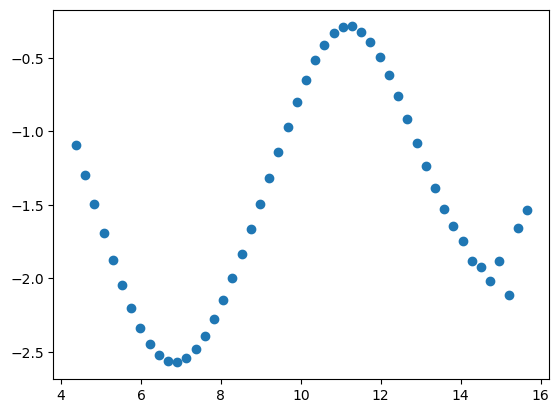

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('/home/tiwari/in16bdielectricwf/data/windeta-21837.diel',sep='\t',skiprows=6)
# df[:,10]
plt.plot(np.log(df.iloc[:,0]),np.log(df.iloc[:,4]),'o')
plt.show()

In [ ]:
## Just to print missing file number in sequence for beamtime dielectric data ploting 
directory = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/'

start = 12420134
end = 12420169
diff=(end-start)

all_data = pd.DataFrame()

missing=[]

for i in range(start, end+1 ):
    
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

 
    
    if os.path.exists(file_path):
        with open(file_path, 'r') as file_content:
            content = file_content.read()
            
       
        df = pd.read_csv(file_path, sep='\t', skiprows=1)
        
        
        all_data = pd.concat([all_data, df], ignore_index=True)
       
    else:
        
        files= i
        missing.append(i)

print(missing)


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[2:-1]

    return df,i


path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp=[330,300,270,250,220,200,180,150,200,330,300,270,250,220,200,180,150,330,300,270,250,220,200,180,150,200,330,300,270,250,220,200,180,150]
skip1=[12420135, 12420152, 12420155]
G5P_D = [load_diel(path, i) for i in range(12420136, 12420169) if i not in skip1]

for df, file_number,t in zip(G5P_D,G5P_D,Temp):
    
    x = df.iloc[:, 0]
    y_columns = df.columns[3::2] 
    error_columns = df.columns[4::2]  
    
    plt.figure(figsize=(12, 8))

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)]  # Cycle through marker styles
        plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col} ± {err_col}', capsize=5, linestyle='None')

    plt.xscale('log')
    # plt.yscale('log')
    plt.xlabel('Time')
    plt.ylabel('Echo Values')
    plt.title(f'Time vs Echo - File: MD_e_{file_number}_{t}.txt')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    # Skip 5 data points from the beginning and end
    df = df.iloc[2:-1]

    return df, i

# Path to the directory containing the text files
path = "path_to_your_directory"

# List of DataFrames and their corresponding file numbers for each file
G5P_D = [load_diel(path, i) for i in range(12420134, 12420169)]

for df, file_number in G5P_D:
    x = df.iloc[:, 0]
    y_columns = df.columns[3::2] 
    error_columns = df.columns[4::2]  
    
    plt.figure(figsize=(12, 8))

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)]  # Cycle through marker styles
        plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col} ± {err_col}', capsize=5, linestyle='None')

    plt.xscale('log')
    # plt.yscale('log')
    plt.xlabel('Time')
    plt.ylabel('Echo Values')
    plt.title(f'Plot of Time vs Echo Values with Error Bars - File: MD_e_{file_number}.txt')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    # df = df.iloc[2:-1]

    return df, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp = [330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150, 330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150]
skip1 = [12420135, 12420152, 12420155]
G5P_D = [load_diel(path, i) for i in range(12420136, 12420169) if i not in skip1]

for (df, file_number), t in zip(G5P_D, Temp):
    
    x = df.iloc[:, 0]
    y_columns = df.columns[3::2] 
    error_columns = df.columns[4::2]  
    
    plt.figure(figsize=(10, 6))

    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)]  
        plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col}', capsize=3, linestyle='None')
        # plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Plots_WASP/f'WASP_echo{file_number}_T={t}K.pdf')

    plt.xscale('log')
    # plt.yscale('log')
    plt.xlabel('Time')
    plt.ylabel('Echo Values')
    plt.title(f'Time vs Echo  {file_number}  T={t}K')
    
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.1, ncol=1, fontsize='5.7')  
    plt.grid(True)
    plt.show()
    plt.savefig('/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Plots_WASP/WASP_echo.pdf')


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    df = df.iloc[2:-1]

    return df, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp = [330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150, 330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150]
skip1 = [12420135, 12420152, 12420155]
G5P_D = [load_diel(path, i) for i in range(12420136, 12420169) if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Plots_WASP/WASP_echo.pdf'

with PdfPages(output_pdf_path) as pdf:
    for (df, file_number), t in zip(G5P_D, Temp):
        
        x = df.iloc[:, 0]
        y_columns = df.columns[3::2] 
        error_columns = df.columns[4::2]  

        plt.figure(figsize=(10, 6))
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

        for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
            marker = markers[i % len(markers)]  
            plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col}', capsize=3, linestyle='None')

        plt.xscale('log')
        plt.xlabel('Time(ns)')
        plt.ylabel('Echo Values')
        plt.title(f'Time vs Echo  {file_number}  T={t}K')
        
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.1, ncol=1, fontsize='small')  
        plt.grid(True)
        
        pdf.savefig()  # Save the current figure into the PDF
        plt.close()    # Close the figure to avoid memory issues

print(f'All plots have been saved in {output_pdf_path}')


In [ ]:
#5G5P(D) time VS echo   

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    df = df.iloc[2:-1]

    return df, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp = [330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150, 330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150]

skip1 = [12420135, 12420152, 12420155]
G5P_D = [load_diel(path, i) for i in range(12420134, 12420142+1) if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Plots_WASP/WASP_echo_5G5P(D).pdf'

with PdfPages(output_pdf_path) as pdf:
    for (df, file_number), t in zip(G5P_D, Temp):
        
        x = df.iloc[:, 0]
        y_columns = df.columns[3::2] 
        error_columns = df.columns[4::2]  

        plt.figure(figsize=(12, 8))
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

        for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
            marker = markers[i % len(markers)]  
            plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col}', capsize=3, linestyle='None')

        plt.xscale('log')
        # plt.xscale('function', functions=(np.log, np.exp))
        plt.xlabel('Time(ns)')
        plt.ylabel('Echo Values')
        plt.title(f'Time vs Echo 5G5P(D) {file_number}  T={t}K')
        
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.1, ncol=1, fontsize='small')  
        plt.grid(True)
        
        plt.show()  # 
        pdf.savefig()  #
        # plt.close()    # 

print(f'All plots have been saved in {output_pdf_path}')


In [ ]:
#5G5P(H) time VS echo   
def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    df = df.iloc[2:-1]

    return df, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp = [330, 300, 270, 250, 220, 200, 180, 150, 330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150]

skip1 = [12420135, 12420152, 12420155]
G5P_D = [load_diel(path, i) for i in range(12420144, 12420151+1) if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Plots_WASP/WASP_echo_5G5P(H).pdf'

with PdfPages(output_pdf_path) as pdf:
    for (df, file_number), t in zip(G5P_D, Temp):
        
        x = df.iloc[:, 0]
        y_columns = df.columns[3::2] 
        error_columns = df.columns[4::2]  

        plt.figure(figsize=(12, 8))
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

        for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
            marker = markers[i % len(markers)]  
            plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col}', capsize=3, linestyle='None')

        plt.xscale('log')
        # plt.xscale('function', functions=(np.log, np.exp))
        plt.xlabel('Time(ns)')
        plt.ylabel('Echo Values')
        plt.title(f'Time vs Echo 5G5P(H) {file_number}  T={t}K')
        
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.1, ncol=1, fontsize='small')  
        plt.grid(True)
        
        plt.show()  
        pdf.savefig()  
        # plt.close()    

print(f'All plots have been saved in {output_pdf_path}')


In [ ]:
#2G8P(D) time VS echo   here 270K 12420155 missing
def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    df = df.iloc[2:-1]

    return df, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp = [330, 300, 250, 220, 200, 180, 150, 330, 300, 270, 250, 220, 200, 180, 150, 200, 330, 300, 270, 250, 220, 200, 180, 150]

skip1 = [12420135, 12420152, 12420155]
G5P_D = [load_diel(path, i) for i in range(12420153, 12420160+1) if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Plots_WASP/WASP_echo_2G8P(D).pdf'

with PdfPages(output_pdf_path) as pdf:
    for (df, file_number), t in zip(G5P_D, Temp):
        
        x = df.iloc[:, 0]
        y_columns = df.columns[3::2] 
        error_columns = df.columns[4::2]  

        plt.figure(figsize=(12, 8))
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

        for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
            marker = markers[i % len(markers)]  
            plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col}', capsize=3, linestyle='None')

        plt.xscale('log')
        # plt.xscale('function', functions=(np.log, np.exp))
        plt.xlabel('Time(ns)')
        plt.ylabel('Echo Values')
        plt.title(f'Time vs Echo 2G8P(D) {file_number}  T={t}K')
        
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.1, ncol=1, fontsize='small')  
        plt.grid(True)
        
        plt.show()  
        pdf.savefig()  #
        # plt.close()    
print(f'All plots have been saved in {output_pdf_path}')


In [ ]:
#2G8P(H) time VS echo   here 270K 12420155 missing
def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    with open(file_path, 'r') as file_content:
        content = file_content.read()
        
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    
    df = df.iloc[2:-1]

    return df, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp = [ 330, 300, 270, 250, 220, 200, 180, 150]

skip1 = [12420135, 12420152, 12420155]
G5P_D = [load_diel(path, i) for i in range(12420162, 12420169+1) if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Plots_WASP/WASP_echo_2G8P(H).pdf'

with PdfPages(output_pdf_path) as pdf:
    for (df, file_number), t in zip(G5P_D, Temp):
        
        x = df.iloc[:, 0]
        y_columns = df.columns[3::2] 
        error_columns = df.columns[4::2]  

        plt.figure(figsize=(12, 8))
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

        for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
            marker = markers[i % len(markers)]  
            plt.errorbar(x, df[y_col], yerr=df[err_col], fmt=marker, label=f'{y_col}', capsize=3, linestyle='None')

        plt.xscale('log')
        # plt.xscale('function', functions=(np.log, np.exp))
        plt.xlabel('Time(ns)')
        plt.ylabel('Echo Values')
        plt.title(f'Time vs Echo 2G8P(H) {file_number}  T={t}K')
        
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), borderaxespad=0.1, ncol=1, fontsize='small')  
        plt.grid(True)
        
        plt.show()  # 
        pdf.savefig()  # 
        # plt.close()    # 

print(f'All plots have been saved in {output_pdf_path}')


In [ ]:
#5G5P(H)_experimental report 

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]  # Skipping the first row after header
    
    return df, i

# File path
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
# Temp = [330, 250, 220, 200, 180, 150, 130, 10]
Temp = [330, 300, 250, 180]

# skip1 = [12420135, 12420152, 12420155]
# G5P_D = [load_diel(path, i) for i in range(12420144, 12420151+1) if i not in skip1]

# Files to skip
# skip1 = [12420135, 12420152, 12420155]

# Load data
G5P_D = [load_diel(path, i) for i in [12420144,12420145,12420147,12420150] if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix05_H_report2.pdf'
# Create subplots (4 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, gridspec_kw={'hspace': 0})

# Seaborn color palette
color_palette = sns.color_palette("rainbow", n_colors=len(G5P_D[0][0].columns[3::2]))

# Markers
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x']

# Loop through datasets and plot
for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    row, col = divmod(idx, 2)  # 

    x = df.iloc[:, 0]
    y_columns = df.columns[3::2]  # 
    error_columns = df.columns[4::2]  # s  

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)] 
        color = color_palette[i % len(color_palette)]
        axes[row, col].errorbar(x, df[y_col], yerr=df[err_col], fmt=marker,markersize=4, color=color, label=f'{y_col}', capsize=3, linestyle='--')
        axes[row, col].grid(True)


    # Set scientific axis formatting
    axes[row, col].set_xscale('log')
    axes[row, col].set_ylabel('Echo Values')

    # Add (a), (b), (c)... labels in the top-left of each subplot
    subplot_label = f"({chr(97 + idx)}) : {t} K"
    axes[row, col].text(0.4, 0.97, subplot_label, transform=axes[row, col].transAxes,
                    fontsize=8, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='wheat', alpha=0.8))


    
    if row == 1 and col == 1:
        axes[row, col].legend(loc='center left', bbox_to_anchor=(0.01, 0.2), borderaxespad=0.1, ncol=3, fontsize='7')


for ax in axes[:-1, :].flatten():
    ax.set_xlabel('')


for ax in axes[-1, :]:
    ax.set_xlabel('Time (ns)')


plt.tight_layout()
plt.show()


with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig)

print(f'All plots have been saved in {output_pdf_path}')
# print(f'All plots have been saved in {output_pdf_path2}')


In [ ]:
# ==================================================
# IMPORTS
# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ==================================================
#  PLOT STYLE
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (10, 7),
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'legend.fontsize': 9,
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
}
rcParams.update(PLOT_STYLE)

# ==================================================
#  CONTROL PARAMETERS 
# ==================================================
COLORBAR_POSITION = [0.30, 0.48, 0.35, 0.025]  
# [left, bottom, width, height] 

COLORMAP_NAME = 'viridis'   
CBAR_LABEL = r"$Q$ ($\AA^{-1}$)"

# ==================================================
# FUNCTION
# ==================================================
def load_diel(path, i):
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]

    return df, i

# ==================================================
# DATA
# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
Temp = [330, 300, 250, 180]

G5P_D = [load_diel(path, i) for i in [12420144,12420145,12420147,12420150]]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix05_H_report2.pdf'

# ==================================================
# FIGURE SETUP
# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True)
axes = axes.flatten()

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.10, top=0.97, hspace=0.05)

# ==================================================
# EXTRACT Q VALUES
# ==================================================
sample_df = G5P_D[0][0]
q_labels = sample_df.columns[3::2]


try:
    q_values = np.array([float(q.split('_')[-1]) for q in q_labels])
except:
    q_values = np.arange(len(q_labels))

# ==================================================
# COLORMAP SETUP
# ==================================================
cmap = cm.get_cmap(COLORMAP_NAME)
norm = mcolors.Normalize(vmin=min(q_values), vmax=max(q_values))

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

# ==================================================
# PLOTTING
# ==================================================
for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):

    ax = axes[idx]
    ax.set_facecolor('#F5F7FA')

    x = df.iloc[:, 0]
    y_columns = df.columns[3::2]
    error_columns = df.columns[4::2]

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):

        color = cmap(norm(q_values[i]))

        ax.errorbar(
            x,
            df[y_col],
            yerr=df[err_col],
            fmt=markers[i % len(markers)],
            markersize=3,
            markerfacecolor='white',
            color=color,
            linestyle='--',
            linewidth=1.2,
            capsize=2,
            alpha=0.9
        )

    # ===== AXIS STYLE =====
    ax.set_xscale('log')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.tick_params(direction='out', width=1, size=3)

    # ===== LABELS =====
    ax.set_ylabel('Echo (a.u.)')

    # ===== SUBPLOT LABEL =====
    ax.text(
        0.03, 0.88,
        f"({chr(97 + idx)})  {t} K",
        transform=ax.transAxes,
        fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25',
                  facecolor='blanchedalmond',
                  edgecolor='orange')
    )

# ==================================================
# X LABELS
# ==================================================
for ax in axes[:2]:
    ax.set_xlabel('')

for ax in axes[2:]:
    ax.set_xlabel('Time (ns)')

# ==================================================
# COLORBAR 
# ==================================================
cax = fig.add_axes(COLORBAR_POSITION)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')

cbar.set_label(CBAR_LABEL, fontsize=11)
cbar.ax.tick_params(labelsize=9)


cbar.set_ticks(np.linspace(min(q_values), max(q_values), 4))

# ==================================================
# SAVE
# ==================================================
plt.tight_layout(rect=[0.09, 0.05, 0.2, 0.2])

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig, dpi=300)

print(f'✅ Saved to: {output_pdf_path}')

plt.show()

✅ Successfully saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix05_H_report2.pdf


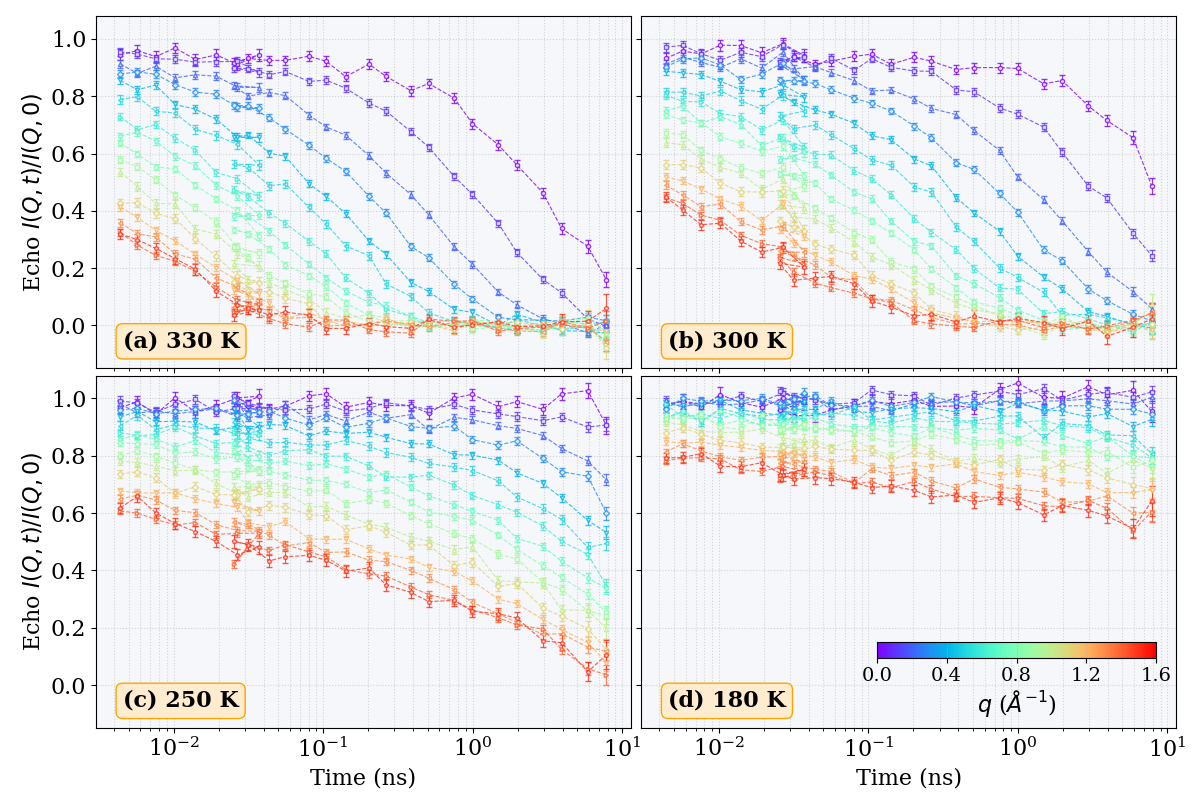

In [51]:
# ==================================================
# IMPORTS  WASP_echo_Mix05_H_report2 Thesis 
# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==================================================
#  PLOT STYLE
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)

# ==================================================
#  CONTROL PARAMETERS
# ==================================================

COLORMAP_NAME = 'rainbow'
CBAR_LABEL = r"$q$ ($\AA^{-1}$)"

# ==================================================
# FUNCTION
# ==================================================
def load_diel(path, i):
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)
    
    
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]
    return df, i

# ==================================================
# DATA 
# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix05_H_report2.pdf'

Temp = [330, 300, 250, 180]
ids = [12420144, 12420145, 12420147, 12420150]

# Pre-loading data
G5P_D = []
for i in ids:
    try:
        G5P_D.append(load_diel(path, i))
    except FileNotFoundError:
        print(f"Warning: File for ID {i} not found. Using dummy data for demonstration.")
        # Dummy data creator for script testing if files are missing
        dummy_df = pd.DataFrame(np.random.rand(10, 20))
        dummy_df.columns = [f'col_{j}' for j in range(20)]
        G5P_D.append((dummy_df, i))

# ==================================================
# FIGURE SETUP
# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes = axes.flatten()


fig.subplots_adjust(left=0.08, right=0.98, bottom=0.09, top=0.98, hspace=0.02, wspace=0.02)

# ==================================================
# EXTRACT Q VALUES
# ==================================================
sample_df = G5P_D[0][0]
q_labels = sample_df.columns[3::2]

try:
    q_values = np.array([float(q.split('_')[-1]) for q in q_labels])
except:
    q_values = np.arange(len(q_labels))/10

# ==================================================
# COLORMAP SETUP
# ==================================================
cmap = plt.get_cmap(COLORMAP_NAME)
norm = mcolors.Normalize(vmin=min(q_values), vmax=max(q_values))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

# ==================================================
# PLOTTING
# ==================================================
for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    ax = axes[idx]
    ax.set_facecolor('#F5F7FA')

    x = pd.to_numeric(df.iloc[:, 0])
    y_columns = df.columns[3::2]
    error_columns = df.columns[4::2]

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        color = cmap(norm(q_values[i]))
        
        ax.errorbar(
            x,
            pd.to_numeric(df[y_col]),
            yerr=pd.to_numeric(df[err_col]),
            fmt=markers[i % len(markers)],
            markersize=3,
            markerfacecolor='white',
            markeredgewidth=1,
            color=color,
            linestyle='--',
            linewidth=0.8,
            capsize=2,
            alpha=0.8
        )

    
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.set_ylim([-0.15,1.08])
    # Labels
    if idx % 2 == 0:
        ax.set_ylabel('Echo $I(Q,t)/I(Q,0)$')
    
    if idx >= 2:
        ax.set_xlabel('Time (ns)')

    # Subplot Annotation
    ax.text(
        0.05, 0.06,
        f"({chr(97 + idx)}) {t} K",
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange')
    )

# ==================================================
# COLORBAR (INSET DESIGN)
# ==================================================

cax = inset_axes(axes[1],
                 width="55%",      
                 height="5%",      
                 loc='lower right',
                 bbox_to_anchor=(0.013, 0.2, 0.95, 0.9), 
                 bbox_transform=axes[3].transAxes,
                 borderpad=0)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(CBAR_LABEL, fontsize=16, labelpad=2)
cbar.ax.tick_params(labelsize=14)


tick_pts = np.linspace(min(q_values), max(q_values), 5)
cbar.set_ticks(tick_pts)
cbar.ax.set_xticklabels([f"{val:.1f}" for val in tick_pts])

# ==================================================
# SAVE 
# ==================================================

os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    
    pdf.savefig(fig)

print(f'✅ Successfully saved to: {output_pdf_path}')
plt.show()

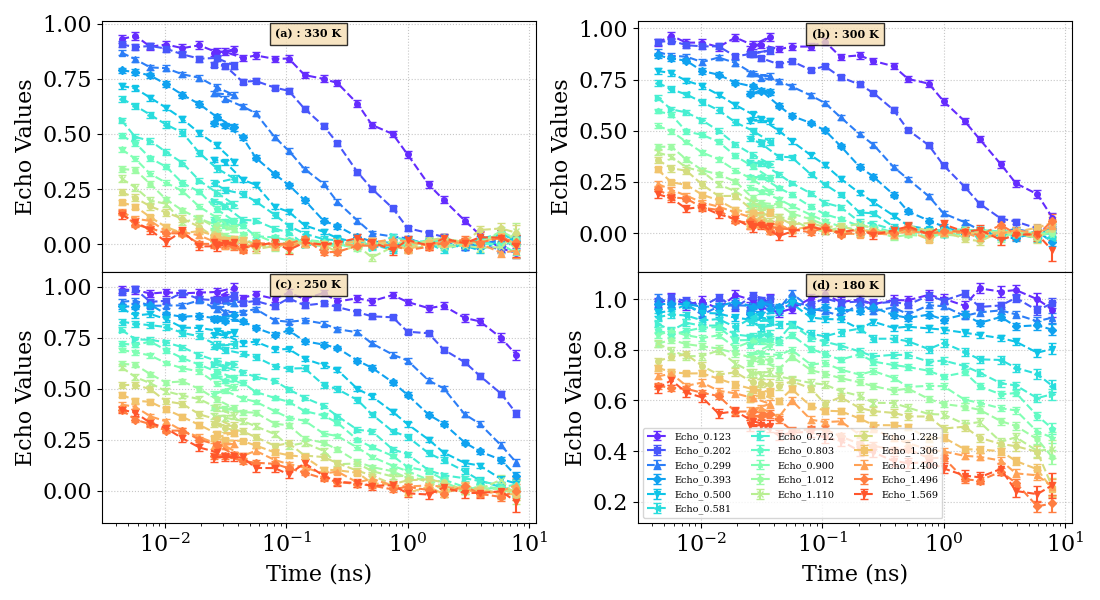

All plots have been saved in /home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix02_H_report2.pdf


In [47]:
#2G8P(H)_experimental report 

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:] 
    
    return df, i

# File path
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
# Temp = [330, 250, 220, 200, 180, 150, 130, 10]
Temp = [330, 300, 250, 180]

# skip1 = [12420135, 12420152, 12420155]
# G5P_D = [load_diel(path, i) for i in range(12420144, 12420151+1) if i not in skip1]

# Files to skip
# skip1 = [12420135, 12420152, 12420155]

# Load data
G5P_D = [load_diel(path, i) for i in [12420162,12420163,12420165,12420168] if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix02_H_report2.pdf'

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, gridspec_kw={'hspace': 0})


color_palette = sns.color_palette("rainbow", n_colors=len(G5P_D[0][0].columns[3::2]))


markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x']


for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    row, col = divmod(idx, 2)  

    x = df.iloc[:, 0]
    y_columns = df.columns[3::2]  
    error_columns = df.columns[4::2]    

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)] 
        color = color_palette[i % len(color_palette)]
        axes[row, col].errorbar(x, df[y_col], yerr=df[err_col], fmt=marker,markersize=4, color=color, label=f'{y_col}', capsize=3, linestyle='--')
        axes[row, col].grid(True)


    
    axes[row, col].set_xscale('log')
    axes[row, col].set_ylabel('Echo Values')

    # Add (a), (b), (c)... labels in the top-left of each subplot
    subplot_label = f"({chr(97 + idx)}) : {t} K"
    axes[row, col].text(0.4, 0.97, subplot_label, transform=axes[row, col].transAxes,
                    fontsize=8, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='wheat', alpha=0.8))


   
    if row == 1 and col == 1:
        axes[row, col].legend(loc='center left', bbox_to_anchor=(0.01, 0.2), borderaxespad=0.1, ncol=3, fontsize='7')


for ax in axes[:-1, :].flatten():
    ax.set_xlabel('')


for ax in axes[-1, :]:
    ax.set_xlabel('Time (ns)')


plt.tight_layout()
plt.show()


with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig)

print(f'All plots have been saved in {output_pdf_path}')
# print(f'All plots have been saved in {output_pdf_path2}')


[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6]
✅ Successfully saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix02_H_report2.pdf


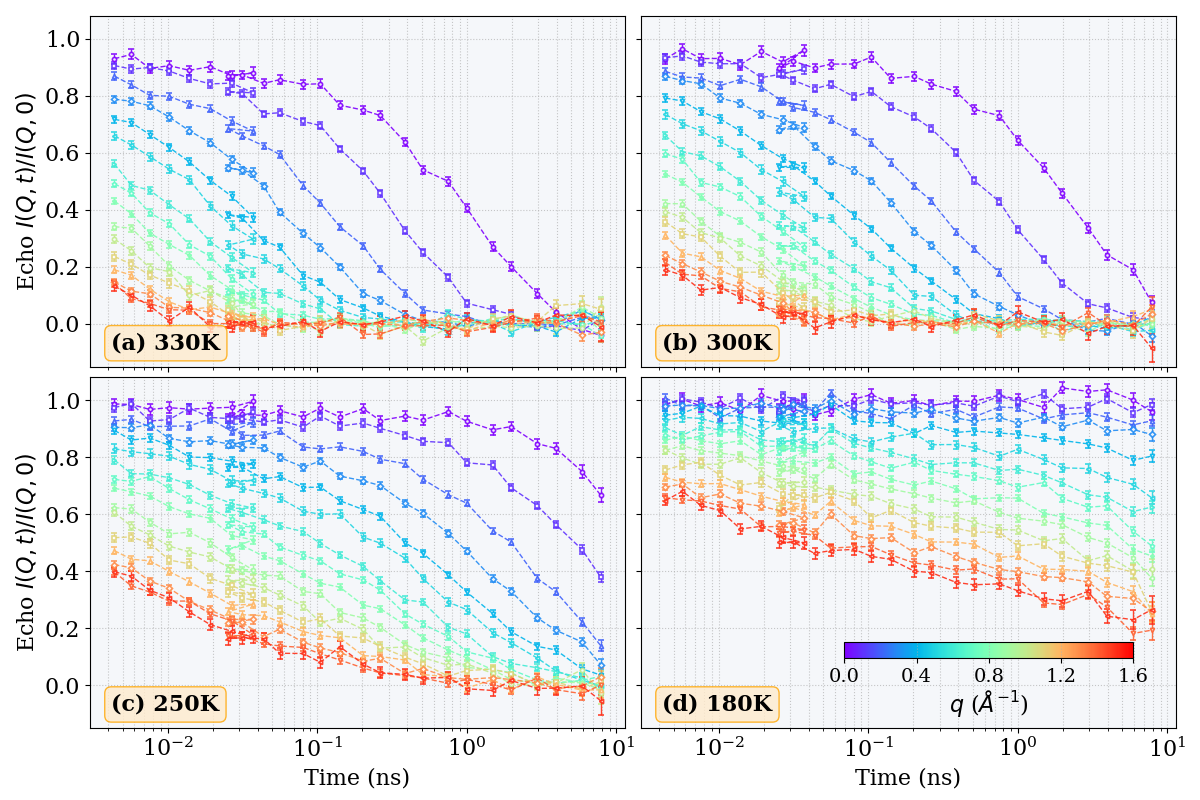

In [12]:
# ==================================================
# IMPORTS - WASP_echo_Mix02_H_report2
# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==================================================
#  PLOT STYLE 
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)

# ==================================================
#  CONTROL PARAMETERS
# ==================================================
COLORMAP_NAME = 'rainbow'
CBAR_LABEL = r"$q$ ($\AA^{-1}$)"
skip1 = [12420135, 12420152, 12420155]

# ==================================================
# FUNCTION
# ==================================================
def load_diel(path, i):
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]  # Skipping metadata row
    return df, i

# ==================================================
# DATA PATHS & LOADING
# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix02_H_report2.pdf'

Temp = [330, 300, 250, 180]
ids = [12420162, 12420163, 12420165, 12420168]

G5P_D = [load_diel(path, i) for i in ids if i not in skip1]

# ==================================================
# FIGURE SETUP
# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes = axes.flatten()

fig.subplots_adjust(left=0.075, right=0.98, bottom=0.09, top=0.98, hspace=0.03, wspace=0.03)

# ==================================================
# EXTRACT Q VALUES FOR COLORING
# ==================================================
sample_df = G5P_D[0][0]
q_labels = sample_df.columns[3::2]

try:
    q_values = np.array([float(q.split('_')[-1]) for q in q_labels])
except:
    q_values = np.arange(len(q_labels))/10

print(q_values)
# ==================================================
# ==================================================
cmap = plt.get_cmap(COLORMAP_NAME)
norm = mcolors.Normalize(vmin=min(q_values), vmax=max(q_values))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# ==================================================
# PLOTTING LOOP
# ==================================================
for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    ax = axes[idx]
    ax.set_facecolor('#F5F7FA')

    x = pd.to_numeric(df.iloc[:, 0])
    y_columns = df.columns[3::2]
    error_columns = df.columns[4::2]

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        color = cmap(norm(q_values[i]))
        
        ax.errorbar(
            x,
            pd.to_numeric(df[y_col]),
            yerr=pd.to_numeric(df[err_col]),
            fmt=markers[i % len(markers)],
            markersize=3,
            markerfacecolor='white',
            markeredgewidth=1.2,
            color=color,
            linestyle='--',
            linewidth=1.0,
            capsize=2,
            alpha=0.9
        )

    # Axis Formatting
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle=':', alpha=0.7)
    ax.set_ylim([-0.15,1.08])
    
    if idx % 2 == 0:
        ax.set_ylabel('Echo $I(Q,t)/I(Q,0)$')
    
    if idx >= 2:
        ax.set_xlabel('Time (ns)')

    ax.text(
        0.040, 0.05,
        f"({chr(97 + idx)}) {t}K",
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='blanchedalmond', edgecolor='orange', alpha=0.8)
    )

# ==================================================
# ==================================================
cax = inset_axes(axes[2],
                 width="60%",      
                 height="5%",      
                 loc='lower right',
                 bbox_to_anchor=(0.02, 0.20, 0.9, 0.9), 
                 bbox_transform=axes[3].transAxes,
                 borderpad=0)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(CBAR_LABEL, fontsize=16, labelpad=2)
cbar.ax.tick_params(labelsize=14)

tick_pts = np.linspace(min(q_values), max(q_values), 5)
cbar.set_ticks(tick_pts)
cbar.ax.set_xticklabels([f"{val:.1f}" for val in tick_pts])

# ==================================================
# ==================================================
os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig)

print(f'✅ Successfully saved to: {output_pdf_path}')
plt.show()

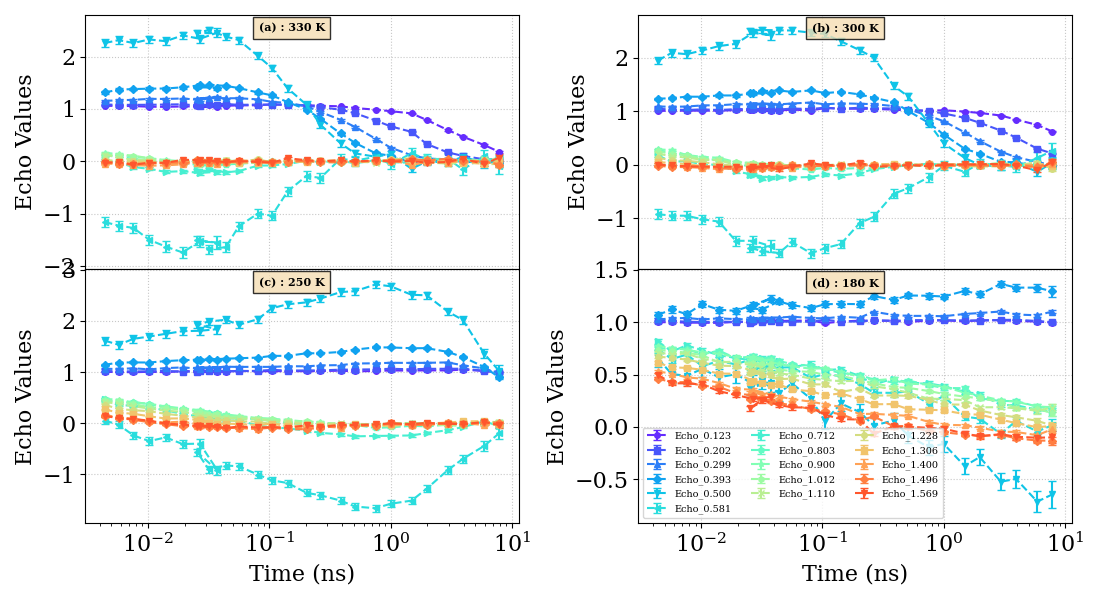

All plots have been saved in /home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix02_D_report2.pdf


In [48]:
#2G8P(D)_experimental report 

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]  # Skipping the first row after header
    
    return df, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
# Temp = [330, 250, 220, 200, 180, 150, 130, 10]
Temp = [330, 300, 250, 180]

# skip1 = [12420135, 12420152, 12420155]
# G5P_D = [load_diel(path, i) for i in range(12420144, 12420151+1) if i not in skip1]

# Files to skip
# skip1 = [12420135, 12420152, 12420155]

# Load data
G5P_D = [load_diel(path, i) for i in [12420153,12420154,12420156,12420159] if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix02_D_report2.pdf'
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, gridspec_kw={'hspace': 0})

color_palette = sns.color_palette("rainbow", n_colors=len(G5P_D[0][0].columns[3::2]))

# Markers
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x']

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    row, col = divmod(idx, 2)  

    x = df.iloc[:, 0]
    y_columns = df.columns[3::2]  
    error_columns = df.columns[4::2]    

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)] 
        color = color_palette[i % len(color_palette)]
        axes[row, col].errorbar(x, df[y_col], yerr=df[err_col], fmt=marker,markersize=4, color=color, label=f'{y_col}', capsize=3, linestyle='--')
        axes[row, col].grid(True)


    
    axes[row, col].set_xscale('log')
    axes[row, col].set_ylabel('Echo Values')

    # Add (a), (b), (c)... labels in the top-left of each subplot
    subplot_label = f"({chr(97 + idx)}) : {t} K"
    axes[row, col].text(0.4, 0.97, subplot_label, transform=axes[row, col].transAxes,
                    fontsize=8, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='wheat', alpha=0.8))


    
    if row == 1 and col == 1:
        axes[row, col].legend(loc='center left', bbox_to_anchor=(0.01, 0.2), borderaxespad=0.1, ncol=3, fontsize='7')

for ax in axes[:-1, :].flatten():
    ax.set_xlabel('')

for ax in axes[-1, :]:
    ax.set_xlabel('Time (ns)')

plt.tight_layout()
plt.show()

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig)

print(f'All plots have been saved in {output_pdf_path}')
# print(f'All plots have been saved in {output_pdf_path2}')


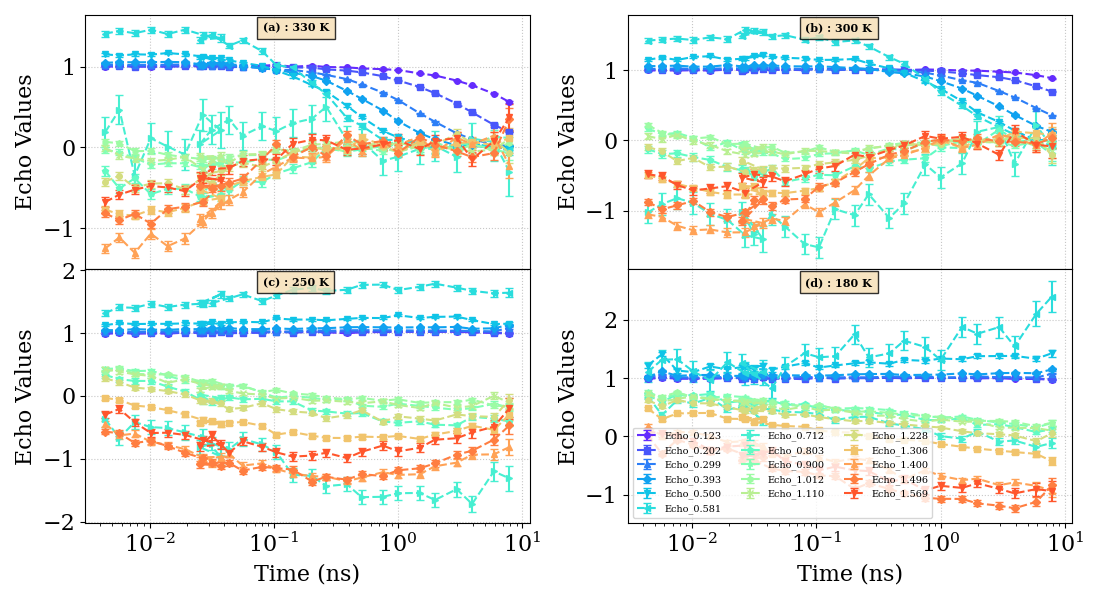

All plots have been saved in /home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix05_D_report2.pdf


In [49]:
#5G5P(D)_experimental report 

def load_diel(path, i):
    """
    Load a text file, skip certain rows, and return a DataFrame.
    """
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)

    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]  # Skipping the first row after header
    
    return df, i

# File path
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
# Temp = [330, 250, 220, 200, 180, 150, 130, 10]
Temp = [330, 300, 250, 180]

# skip1 = [12420135, 12420152, 12420155]
# G5P_D = [load_diel(path, i) for i in range(12420144, 12420151+1) if i not in skip1]

# Files to skip
# skip1 = [12420135, 12420152, 12420155]

# Load data
G5P_D = [load_diel(path, i) for i in [12420134,12420136,12420138,12420141] if i not in skip1]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_echo_Mix05_D_report2.pdf'
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, gridspec_kw={'hspace': 0})

color_palette = sns.color_palette("rainbow", n_colors=len(G5P_D[0][0].columns[3::2]))

# Markers
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'x']

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    row, col = divmod(idx, 2)  

    x = df.iloc[:, 0]
    y_columns = df.columns[3::2]  
    error_columns = df.columns[4::2]  

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        marker = markers[i % len(markers)] 
        color = color_palette[i % len(color_palette)]
        axes[row, col].errorbar(x, df[y_col], yerr=df[err_col], fmt=marker,markersize=4, color=color, label=f'{y_col}', capsize=3, linestyle='--')
        axes[row, col].grid(True)


    axes[row, col].set_xscale('log')
    axes[row, col].set_ylabel('Echo Values')

    # Add (a), (b), (c)... labels in the top-left of each subplot
    subplot_label = f"({chr(97 + idx)}) : {t} K"
    axes[row, col].text(0.4, 0.97, subplot_label, transform=axes[row, col].transAxes,
                    fontsize=8, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='wheat', alpha=0.8))


    if row == 1 and col == 1:
        axes[row, col].legend(loc='center left', bbox_to_anchor=(0.01, 0.2), borderaxespad=0.1, ncol=3, fontsize='7')

for ax in axes[:-1, :].flatten():
    ax.set_xlabel('')

for ax in axes[-1, :]:
    ax.set_xlabel('Time (ns)')

plt.tight_layout()
plt.show()

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig)

print(f'All plots have been saved in {output_pdf_path}')
# print(f'All plots have been saved in {output_pdf_path2}')


✅ Mix05_D Report successfully saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix05_D_report2.pdf


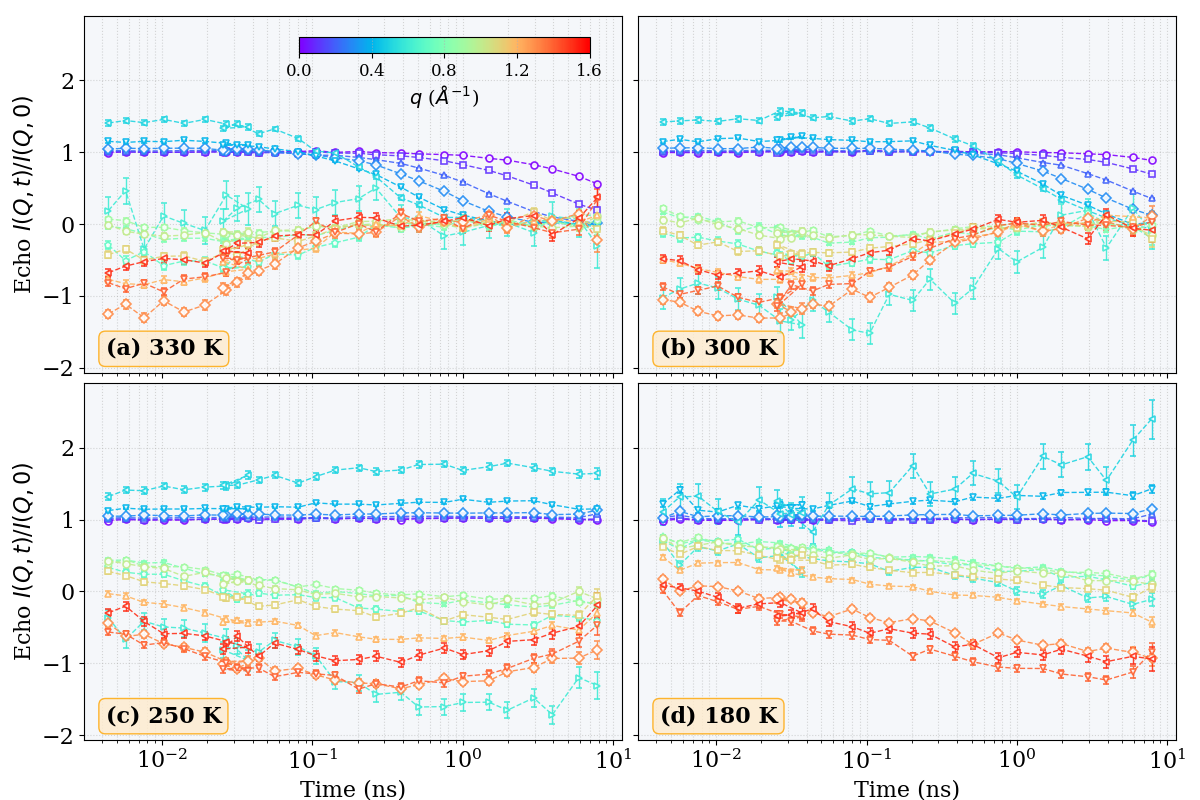

In [50]:
##### ==================================================
# IMPORTS - WASP_echo_Mix05_D_report2 
# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==================================================
# BEST PLOT STYLE 
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)

# ==================================================
#  CONTROL PARAMETERS
# ==================================================
COLORMAP_NAME = 'rainbow'
CBAR_LABEL = r"$q$ ($\AA^{-1}$)"
skip1 = [12420135, 12420152, 12420155]  #

# ==================================================
# FUNCTION
# ==================================================
def load_diel(path, i):
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]  # Skipping metadata row
    return df, i

# ==================================================
# DATA PATHS & LOADING (Mix05_D)
# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix05_D_report2.pdf'

Temp = [330, 300, 250, 180]

ids = [12420134, 12420136, 12420138, 12420141]

G5P_D = [load_diel(path, i) for i in ids if i not in skip1]

# ==================================================
# FIGURE SETUP
# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes = axes.flatten()

fig.subplots_adjust(left=0.07, right=0.98, bottom=0.075, top=0.98, hspace=0.03, wspace=0.03)

# ==================================================
# EXTRACT Q VALUES
# ==================================================
sample_df = G5P_D[0][0]
q_labels = sample_df.columns[3::2]

try:
    q_values = np.array([float(q.split('_')[-1]) for q in q_labels])
except:
    q_values = np.arange(len(q_labels))/10

# ==================================================
# COLORMAP & MARKER SETUP
# ==================================================
cmap = plt.get_cmap(COLORMAP_NAME)
norm = mcolors.Normalize(vmin=min(q_values), vmax=max(q_values))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# ==================================================
# PLOTTING LOOP
# ==================================================
for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    ax = axes[idx]
    ax.set_facecolor('#F5F7FA')

    x = pd.to_numeric(df.iloc[:, 0])
    y_columns = df.columns[3::2]
    error_columns = df.columns[4::2]

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        color = cmap(norm(q_values[i]))
        
        ax.errorbar(
            x,
            pd.to_numeric(df[y_col]),
            yerr=pd.to_numeric(df[err_col]),
            fmt=markers[i % len(markers)],
            markersize=5,
            markerfacecolor='white',
            markeredgewidth=1.2,
            color=color,
            linestyle='--',
            linewidth=1.0,
            capsize=2,
            alpha=0.9
        )

    # Formatting
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    
    if idx % 2 == 0:
        ax.set_ylabel('Echo $I(Q,t)/I(Q,0)$')
    if idx >= 2:
        ax.set_xlabel('Time (ns)')

    ax.text(
        0.040, 0.05,
        f"({chr(97 + idx)}) {t} K",
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='blanchedalmond', edgecolor='orange', alpha=0.8)
    )

# ==================================================
# COLORBAR (
# ==================================================
cax = inset_axes(axes[2],
                 width="60%",      
                 height="5%",      
                 loc='upper right',
                 bbox_to_anchor=(0.04, 0.040, 0.9, 0.9), 
                 bbox_transform=axes[0].transAxes,
                 borderpad=0)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(CBAR_LABEL, fontsize=14, labelpad=2)
cbar.ax.tick_params(labelsize=12)

# Specific ticks for Q values
tick_pts = np.linspace(min(q_values), max(q_values), 5)
cbar.set_ticks(tick_pts)
cbar.ax.set_xticklabels([f"{val:.1f}" for val in tick_pts])

# ==================================================

# ==================================================
os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    
    pdf.savefig(fig)

print(f'✅ Mix05_D Report successfully saved to: {output_pdf_path}')
plt.show()

✅ Mix02_D Report successfully saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix02_D_report2.pdf


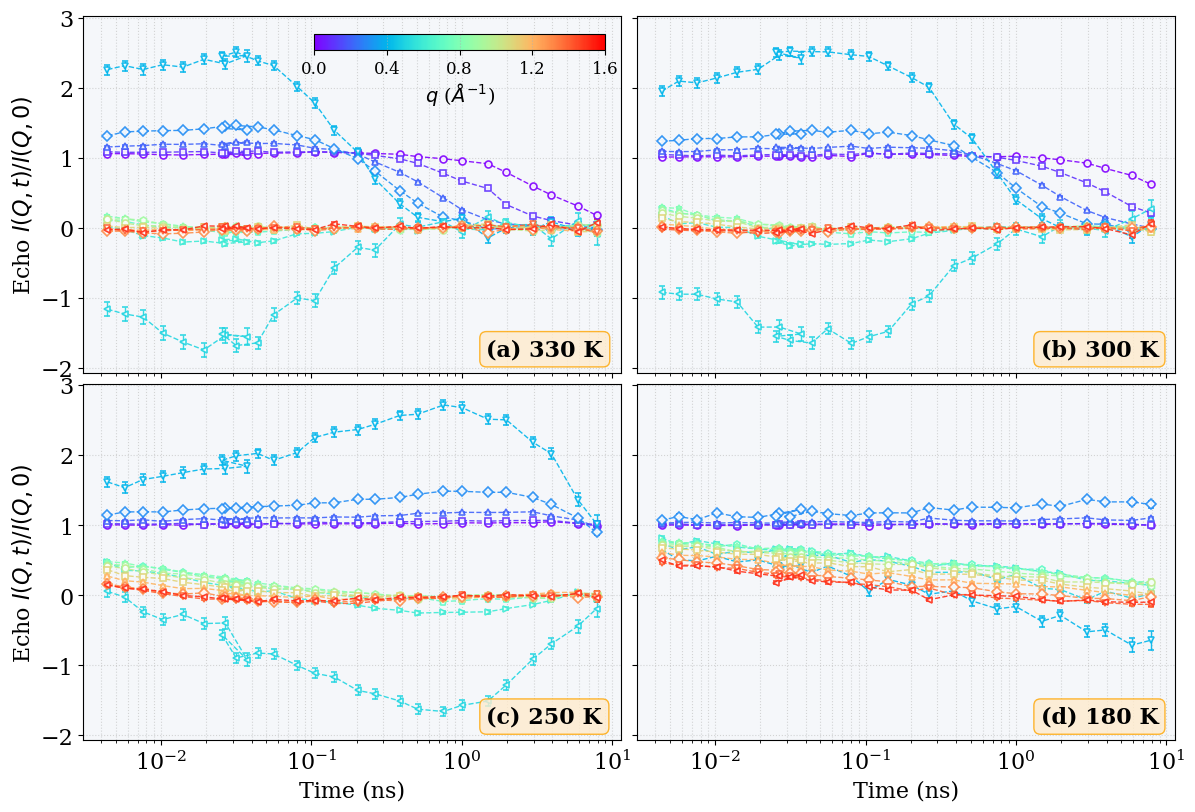

In [6]:
# ==================================================
# IMPORTS - WASP_echo_Mix02_D 
# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==================================================
#  PLOT STYLE
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)

# ==================================================
#  CONTROL PARAMETERS
# ==================================================
COLORMAP_NAME = 'rainbow'
CBAR_LABEL = r"$q$ ($\AA^{-1}$)"
skip1 = [12420135, 12420152, 12420155]  

# ==================================================
# FUNCTION
# ==================================================
def load_diel(path, i):
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]  # Skipping metadata row
    return df, i

# ==================================================
# DATA PATHS & LOADING (Mix02_D)
# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/WASP_echo_Mix02_D_report2.pdf'

Temp = [330, 300, 250, 180]

ids = [12420153, 12420154, 12420156, 12420159]

G5P_D = [load_diel(path, i) for i in ids if i not in skip1]

# ==================================================
# FIGURE SETUP
# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes = axes.flatten()


fig.subplots_adjust(left=0.07, right=0.98, bottom=0.075, top=0.98, hspace=0.03, wspace=0.03)

# ==================================================
# EXTRACT Q VALUES
# ==================================================
sample_df = G5P_D[0][0]
q_labels = sample_df.columns[3::2]

try:
    q_values = np.array([float(q.split('_')[-1]) for q in q_labels])
except:
    
    q_values = np.arange(len(q_labels))/10

# ==================================================
# COLORMAP & MARKER SETUP
# ==================================================
cmap = plt.get_cmap(COLORMAP_NAME)
norm = mcolors.Normalize(vmin=min(q_values), vmax=max(q_values))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# ==================================================
# PLOTTING LOOP
# ==================================================
for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    ax = axes[idx]
    ax.set_facecolor('#F5F7FA')

    x = pd.to_numeric(df.iloc[:, 0])
    y_columns = df.columns[3::2]
    error_columns = df.columns[4::2]

    for i, (y_col, err_col) in enumerate(zip(y_columns, error_columns)):
        color = cmap(norm(q_values[i]))
        
        ax.errorbar(
            x,
            pd.to_numeric(df[y_col]),
            yerr=pd.to_numeric(df[err_col]),
            fmt=markers[i % len(markers)],
            markersize=5,
            markerfacecolor='white',
            markeredgewidth=1.2,
            color=color,
            linestyle='--',
            linewidth=1.0,
            capsize=2,
            alpha=0.9
        )

    # Formatting
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    
   
    if idx % 2 == 0:
        ax.set_ylabel('Echo $I(Q,t)/I(Q,0)$')
    if idx >= 2:
        ax.set_xlabel('Time (ns)')

    
    ax.text(
        0.75, 0.05,
        f"({chr(97 + idx)}) {t} K",
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='blanchedalmond', edgecolor='orange', alpha=0.8)
    )

# ==================================================
# COLORBAR 
# ==================================================
cax = inset_axes(axes[2],
                 width="60%",      
                 height="5%",      
                 loc='upper right',
                 bbox_to_anchor=(0.07, 0.050, 0.9, 0.9), 
                 bbox_transform=axes[0].transAxes, #
                 borderpad=0)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(CBAR_LABEL, fontsize=14, labelpad=2)
cbar.ax.tick_params(labelsize=12)

# Format ticks for Q values
tick_pts = np.linspace(min(q_values), max(q_values), 5)
cbar.set_ticks(tick_pts)
cbar.ax.set_xticklabels([f"{val:.1f}" for val in tick_pts])

# ==================================================
# SAVE & SHOW
# ==================================================
if not os.path.exists(os.path.dirname(output_pdf_path)):
    os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig)

print(f'✅ Mix02_D Report successfully saved to: {output_pdf_path}')
plt.show()

In [5]:
#MixH
def load_diel(path, i):
    file_name = f"MD_DIF_{i}.txt"
    file_path = os.path.join(path, file_name)

    try:
        df = pd.read_csv(file_path, sep='\t', skiprows=3)
        df = df.iloc[1:] 
        return df, i
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return None, i

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/Export_6-05-1049_new/"
 
file_numbers = [12120580,12120581,12120582,12120583,12120584,12120585,12120586,12120587] 
Temp = [330, 280,250, 220, 200, 180, 150, 130]

G5P_D = [load_diel(path, i) for i in file_numbers if i not in skip1]
G5P_D = [(df, i) for df, i in G5P_D if df is not None]

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_dif_up_Mix_H_single.pdf'

plt.figure(figsize=(14, 10))
color_palette = sns.color_palette("viridis", n_colors=len(G5P_D))

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    q = df.iloc[:, 0] 
    up = df.iloc[:, 1]  
    upErr = df.iloc[:, 2]  
    color = color_palette[idx]
    plt.errorbar(q, up, yerr=upErr, fmt='o', color=color, label=f'T={t}K ({file_number})', capsize=3, linestyle='--')


# plt.xscale('log')
plt.xlabel('q ($\\AA^{-1}$)', fontsize=14)
plt.ylabel('Up', fontsize=14)
plt.title(' Up vs Q Mix(H)', fontsize=16)
plt.legend(loc='lower left', fontsize='small') #bbox_to_anchor=(1, 0.5)
plt.grid(True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig()  
    plt.show()    

print(f'All plots have been saved in {output_pdf_path}')



# single pdf propanol_H q vs down  : MD_Diff_xxxxxx  


output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_dif_down_Mix_H_single.pdf'

plt.figure(figsize=(14, 10))
color_palette = sns.color_palette("viridis", n_colors=len(G5P_D))

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    q = df.iloc[:, 0] 
    down = df.iloc[:, 3] 
    downErr = df.iloc[:, 4]  
    color = color_palette[idx]
    plt.errorbar(q, down, yerr=downErr, fmt='o', color=color, label=f'T={t}K ({file_number})', capsize=3, linestyle='--')


# plt.xscale('log')
plt.xlabel('q ($\\AA^{-1}$)', fontsize=14)  
plt.ylabel('Down', fontsize=14)
plt.title('Down vs Q Mix(H)', fontsize=16)
plt.legend(loc='lower left', fontsize='small') #bbox_to_anchor=(1, 0.5)
plt.grid(True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig()  
    plt.show()    

print(f'All plots have been saved in {output_pdf_path}')


###############

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_dif_average_Mix_H_single.pdf'

plt.figure(figsize=(14, 10))
color_palette = sns.color_palette("viridis", n_colors=len(G5P_D))

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    q = df.iloc[:, 0] 
    average = df.iloc[:, 5] 
    averageErr = df.iloc[:, 6]  
    color = color_palette[idx]
    plt.errorbar(q, average, yerr=averageErr, fmt='o', color=color, label=f'T={t}K ({file_number})', capsize=3, linestyle='--')


# plt.xscale('log')
plt.xlabel('q ($\\AA^{-1}$)', fontsize=14)  
plt.ylabel('Average', fontsize=14)
plt.title('Average vs Q Mix(H)', fontsize=16)
plt.legend(loc='lower left', fontsize='small') #bbox_to_anchor=(1, 0.5)
plt.grid(True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig()  
    plt.show()    

print(f'All plots have been saved in {output_pdf_path}')



# single pdf propanol_H q vs pol  : MD_Diff_xxxxxx   # single pdf propanol_H q vs pol  : MD_Diff_xxxxxx  

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_diffe_pol_Mix_H_single.pdf'

plt.figure(figsize=(14, 10))
color_palette = sns.color_palette("viridis", n_colors=len(G5P_D))

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    q = df.iloc[:, 0] 
    pol = df.iloc[:, 7] 
    polErr = df.iloc[:, 8]  
    color = color_palette[idx]
    plt.errorbar(q, pol, yerr=polErr, fmt='o', color=color, label=f'T={t}K ({file_number})', capsize=3, linestyle='--')


# plt.xscale('log')
plt.xlabel('q ($\\AA^{-1}$)', fontsize=14)  
plt.ylabel('Polarisation', fontsize=14)
plt.title('Polarisation vs Q Mix(H)', fontsize=16)
plt.legend(loc='upper left', fontsize='small') #bbox_to_anchor=(1, 0.5)
plt.grid(True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig()  
    plt.show()    

print(f'All plots have been saved in {output_pdf_path}')


# single pdf propanol_H q vs coh  : MD_Diff_xxxxxx  

output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_dif_coh_Mix_H_single.pdf'

plt.figure(figsize=(14, 10))
color_palette = sns.color_palette("viridis", n_colors=len(G5P_D))

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    q = df.iloc[:, 0] 
    up = df.iloc[:, 9] 
    upErr = df.iloc[:, 10]  
    color = color_palette[idx]
    plt.errorbar(q, up, yerr=upErr, fmt='o', color=color, label=f'T={t}K ({file_number})', capsize=3, linestyle='--')


plt.xlabel('q ($\\AA^{-1}$)', fontsize=14)  
plt.ylabel('Coherent', fontsize=14)
plt.title('Coherent vs Q Mix(H)', fontsize=16)
plt.legend(loc='upper left', fontsize='small') #bbox_to_anchor=(1, 0.5)
plt.grid(True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig()  
    plt.show()    

print(f'All plots have been saved in {output_pdf_path}')

# single pdf propanol_H q vs incoh  : MD_Diff_xxxxxx 


output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_dif_incoh_Mix_H_single.pdf'

plt.figure(figsize=(14, 10))
color_palette = sns.color_palette("viridis", n_colors=len(G5P_D))

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    q = df.iloc[:, 0] 
    up = df.iloc[:, 11] 
    upErr = df.iloc[:, 12]  
    color = color_palette[idx]
    plt.errorbar(q, up, yerr=upErr, fmt='o', color=color, label=f'T={t}K ({file_number})', capsize=3, linestyle='--')


plt.xlabel('q ($\\AA^{-1}$)', fontsize=14)  
plt.ylabel('Incoherent', fontsize=14)
plt.title('Incoherent vs Q Mix(H)', fontsize=16)
plt.legend(loc='upper left', fontsize='small') #bbox_to_anchor=(1, 0.5)
plt.grid(True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig()  
    plt.show()    

print(f'All plots have been saved in {output_pdf_path}')




# single pdf propanol_H q vs pol  : MD_Diff_xxxxxx  



output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/WASP/New_WASP_Daviddata/Export_6-05-1049_new/plots/WASP_dif_CohFr_Mix_H_single.pdf'

plt.figure(figsize=(14, 10))
color_palette = sns.color_palette("viridis", n_colors=len(G5P_D))

for idx, ((df, file_number), t) in enumerate(zip(G5P_D, Temp)):
    q = df.iloc[:, 0] 
    up = df.iloc[:, 13] 
    upErr = df.iloc[:, 14]  
    color = color_palette[idx]
    plt.errorbar(q, up, yerr=upErr, fmt='o', color=color, label=f'T={t}K ({file_number})', capsize=3, linestyle='--')


# plt.xscale('log')
plt.xlabel('q ($\\AA^{-1}$)', fontsize=14)  
plt.ylabel('CohFr', fontsize=14)
plt.title('CohFr vs Q Mix(H)', fontsize=16)
plt.legend(loc='upper left', fontsize='small') #bbox_to_anchor=(1, 0.5)
plt.grid(True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig()  
    plt.show()    

print(f'All plots have been saved in {output_pdf_path}')



NameError: name 'sns' is not defined

<Figure size 1400x1000 with 0 Axes>

✅ All mixtures saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures.pdf


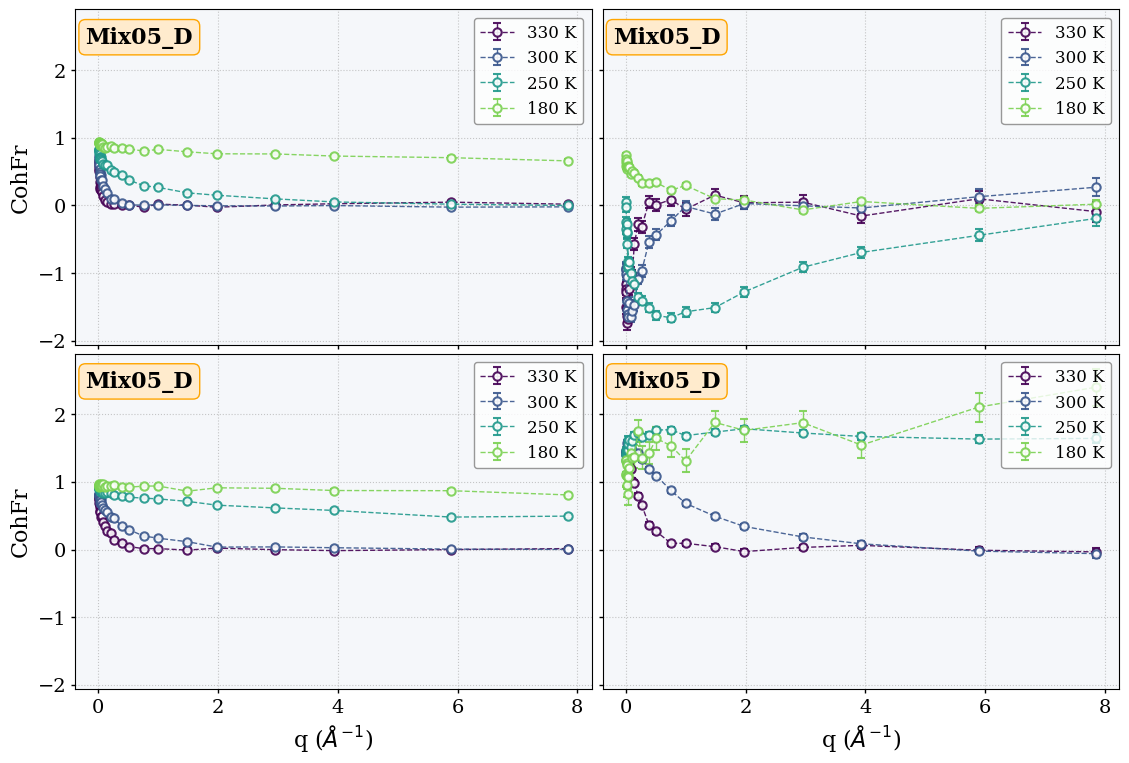

In [7]:
# ==================================================
# 
# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import matplotlib.cm as cm

# ==================================================
# BEST PLOT STYLE 
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)



# ==================================================
# DATA CONFIGURATION
# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures.pdf'


samples = {
    "Mix02_H": [12420162, 12420163, 12420165, 12420168],
    "Mix02_D": [12420153, 12420154, 12420156, 12420159],
    "Mix05_H": [12420144, 12420145, 12420147, 12420150],
    "Mix05_D": [12420134, 12420136, 12420138, 12420141],
}
Temp = [330, 300, 250, 180]
skip1 = [12420135, 12420152, 12420155]

def load_diel(path, i):
    file = f"MD_e_{i}.txt"
    file_path = os.path.join(path, file)
    df = pd.read_csv(file_path, sep='\t', skiprows=1)
    df = df.iloc[1:]  # Skipping metadata row
    return df, i

# ==================================================
# FIGURE SETUP
# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes = axes.flatten()
fig.subplots_adjust(left=0.08, right=0.95, bottom=0.10, top=0.95, hspace=0.025, wspace=0.0210)


titles=['Mix02_H','Mix02_D','Mix05_H','Mix05_D']

# ==================================================

# ==================================================

color_palette = plt.cm.viridis(np.linspace(0, 0.8, len(Temp)))

for ax_idx, (sample_name, ids) in enumerate(samples.items()):
    ax = axes[ax_idx]
    ax.set_facecolor('#F5F7FA')
    
    
    for i, file_id in enumerate(ids):
        if file_id in skip1:
            continue
            
        try:
            df, f_num = load_diel(path, file_id)
            
            
            q = pd.to_numeric(df.iloc[:, 0])
            coh = pd.to_numeric(df.iloc[:, 13])  
            cohErr = pd.to_numeric(df.iloc[:, 14])
            
            ax.errorbar(
                q, coh, yerr=cohErr, 
                fmt='o', 
                markersize=6,
                markerfacecolor='white',
                markeredgewidth=1.5,
                color=color_palette[i], 
                label=f'{Temp[i]} K', 
                capsize=3, 
                linestyle='--', 
                linewidth=1,
                alpha=0.9
            )
        except Exception as e:
            print(f"Error loading ID {file_id}: {e}")

    
    titles=['Mix02_H','Mix02_D','Mix05_H','Mix05_D']
    if ax_idx % 2 == 0:
        ax.set_ylabel('CohFr')
    if ax_idx >= 2:
        ax.set_xlabel('q ($\AA^{-1}$)')
    
    
    ax.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=12, loc='upper right', ncol=1)
    ax.tick_params(direction='out',labelsize=14,  width=1, size=3)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.text(0.02, 0.95, titles[idx], 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='top', 
            bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))
    


   
os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')

print(f'✅ All mixtures saved to: {output_pdf_path}')
plt.show()

✅ All mixtures saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures2.pdf


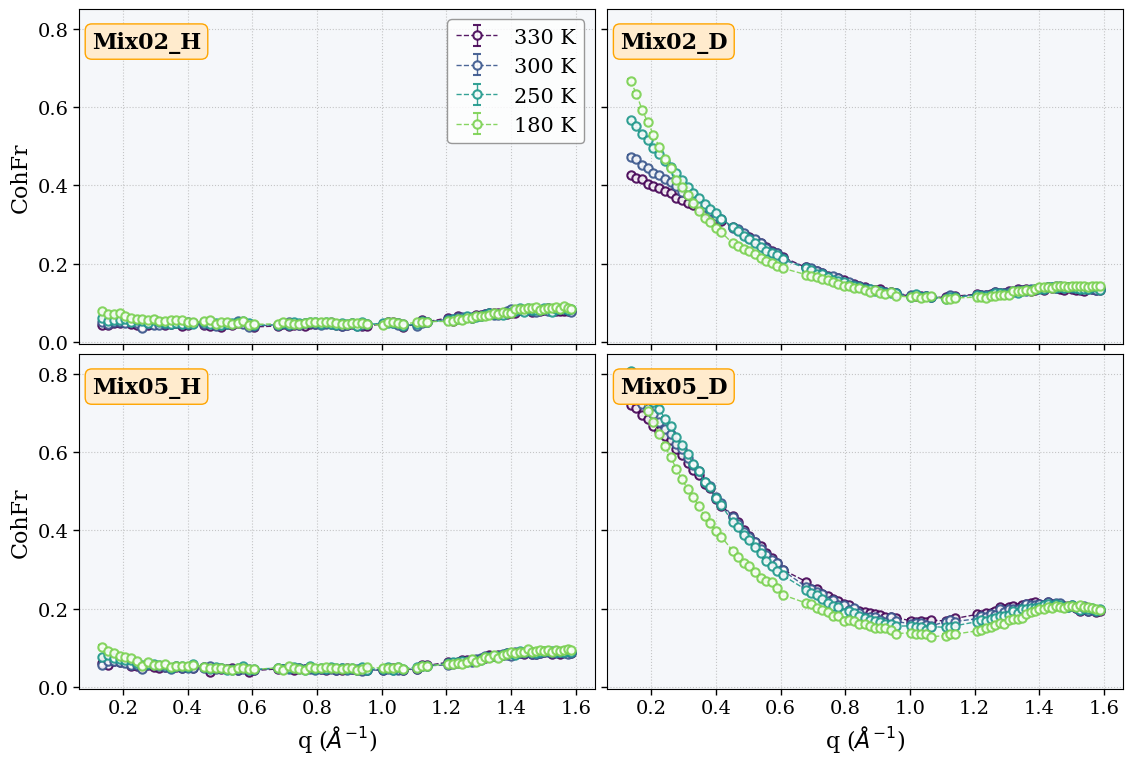

In [9]:
# ==================================================
# 
# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import matplotlib.cm as cm

# ==================================================
#  PLOT STYLE 
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)


path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures2.pdf'

# Dictionary containing mixture labels and their corresponding IDs
samples = {
    "Mix02_H": [12420162, 12420163, 12420165, 12420168],
    "Mix02_D": [12420153, 12420154, 12420156, 12420159],
    "Mix05_H": [12420144, 12420145, 12420147, 12420150],
    "Mix05_D": [12420134, 12420136, 12420138, 12420141],
}

titles = ['Mix02_H', 'Mix02_D', 'Mix05_H', 'Mix05_D']
Temp = [330, 300, 250, 180]
skip1 = [12420135, 12420152, 12420155]

def load_diel(path, i):
    file = f"MD_DIF_{i}.txt"
    file_path = os.path.join(path, file)
    
    df = pd.read_csv(file_path, sep='\s+', skiprows=2)
    df = df.iloc[1:]  
    return df, i

# ==================================================
# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes_flat = axes.flatten()
fig.subplots_adjust(left=0.08, right=0.95, bottom=0.10, top=0.95, hspace=0.03, wspace=0.024)

# ==================================================
#
# ==================================================
color_palette = plt.cm.viridis(np.linspace(0, 0.8, len(Temp)))

for ax_idx, (sample_name, ids) in enumerate(samples.items()):
    ax = axes_flat[ax_idx]
    ax.set_facecolor('#F5F7FA')
    
    
    for i, file_id in enumerate(ids):
        if file_id in skip1:
            continue
            
        try:
            df, f_num = load_diel(path, file_id)
            
           
            q = pd.to_numeric(df.iloc[:, 0], errors='coerce')
            coh = pd.to_numeric(df.iloc[:, 13], errors='coerce')  # Coherent Fraction
            cohErr = pd.to_numeric(df.iloc[:, 14], errors='coerce') # Error
            
            
            valid = ~np.isnan(q) & ~np.isnan(coh)
            
            ax.errorbar(
                q[valid], coh[valid], yerr=cohErr[valid], 
                fmt='o', 
                markersize=6,
                markerfacecolor='white',
                markeredgewidth=1.5,
                color=color_palette[i], 
                label=f'{Temp[i]} K', 
                capsize=3, 
                linestyle='--', 
                linewidth=1,
                alpha=0.9
            )
        except Exception as e:
            print(f"Error loading ID {file_id}: {e}")

    
    if ax_idx % 2 == 0:
        ax.set_ylabel(r'CohFr', fontsize=16)
    if ax_idx >= 2:
        ax.set_xlabel(r'q ($\AA^{-1}$)', fontsize=16)
    
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.tick_params(direction='out', labelsize=14, width=1, size=4)

   
    if ax_idx == 0:
        ax.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=15, loc='upper right', ncol=1)
    else:
        pass
    
    
    
    
    ax.text(0.025, 0.87, titles[ax_idx], 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='bottom', 
            bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))

# ==================================================

# ==================================================
os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')

print(f'✅ All mixtures saved to: {output_pdf_path}')
plt.show()

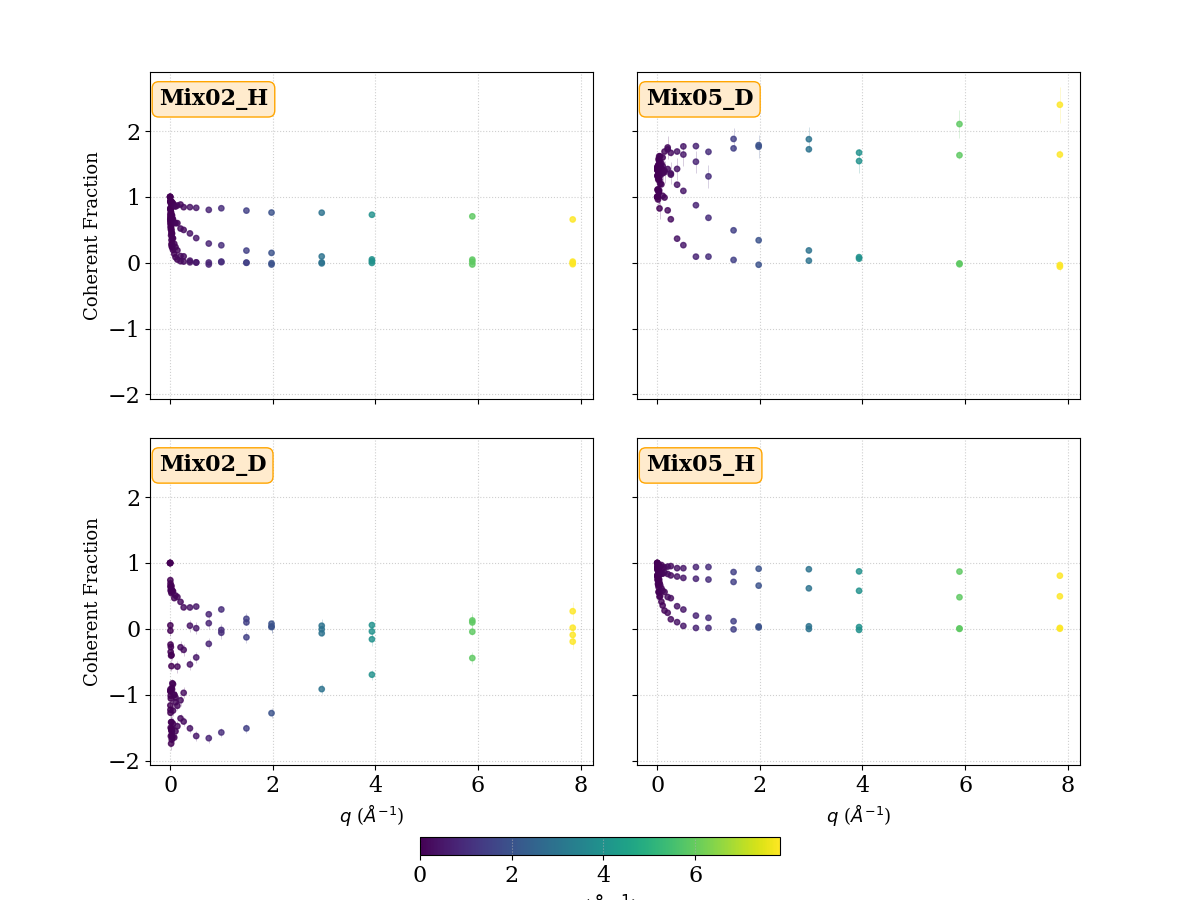

In [67]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']

path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"

samples = {
    "Mix02_H": [12420162, 12420163, 12420165, 12420168],
    "Mix05_D": [12420134, 12420136, 12420138, 12420141],
    "Mix02_D": [12420153, 12420154, 12420156, 12420159],
    "Mix05_H": [12420144, 12420145, 12420147, 12420150]
}
titles = list(samples.keys()) #
skip1 = [12420135, 12420152, 12420155]

def load_data(base_path, file_id):
    file_name = f"MD_e_{file_id}.txt"
    full_path = os.path.join(base_path, file_name)
    if not os.path.exists(full_path): return None
    try:
        df = pd.read_csv(full_path, sep='\s+', skiprows=2, header=None)
        df = df.apply(pd.to_numeric, errors='coerce').dropna()
        return df.iloc[:, 0].values, df.iloc[:, 13].values, df.iloc[:, 14].values
    except: return None

# SETUP
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()
fig.subplots_adjust(bottom=0.15, top=0.92, hspace=0.12, wspace=0.1)

data_store = {}
all_q_vals = []
for name, ids in samples.items():
    data_store[name] = []
    for fid in ids:
        if fid in skip1: continue
        res = load_data(path, fid)
        if res:
            data_store[name].append(res)
            all_q_vals.extend(res[0])

cmap = cm.viridis
norm = mcolors.Normalize(vmin=min(all_q_vals), vmax=max(all_q_vals))

# PLOTTING
for idx, (sample_name, datasets) in enumerate(data_store.items()):
    ax = axes_flat[idx]
    
    for q, coh, err in datasets:
        point_colors = cmap(norm(q))
        ax.scatter(q, coh, c=point_colors, s=15, alpha=0.8, zorder=3)
        ax.errorbar(q, coh, yerr=err, fmt='none', ecolor=point_colors, elinewidth=0.5, alpha=0.3)

    
    ax.text(0.02, 0.95, titles[idx], 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='top', 
            bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))

    ax.grid(True, linestyle=':', alpha=0.6)
    if idx >= 2: ax.set_xlabel(r'$q$ ($\AA^{-1}$)', fontsize=13)
    if idx % 2 == 0: ax.set_ylabel('Coherent Fraction', fontsize=13)

# COLORBAR
cax = fig.add_axes([0.35, 0.05, 0.30, 0.02])
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, cax=cax, orientation='horizontal', label=r'$q$ ($\AA^{-1}$)')

plt.show()

✅ All mixtures saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures2.pdf


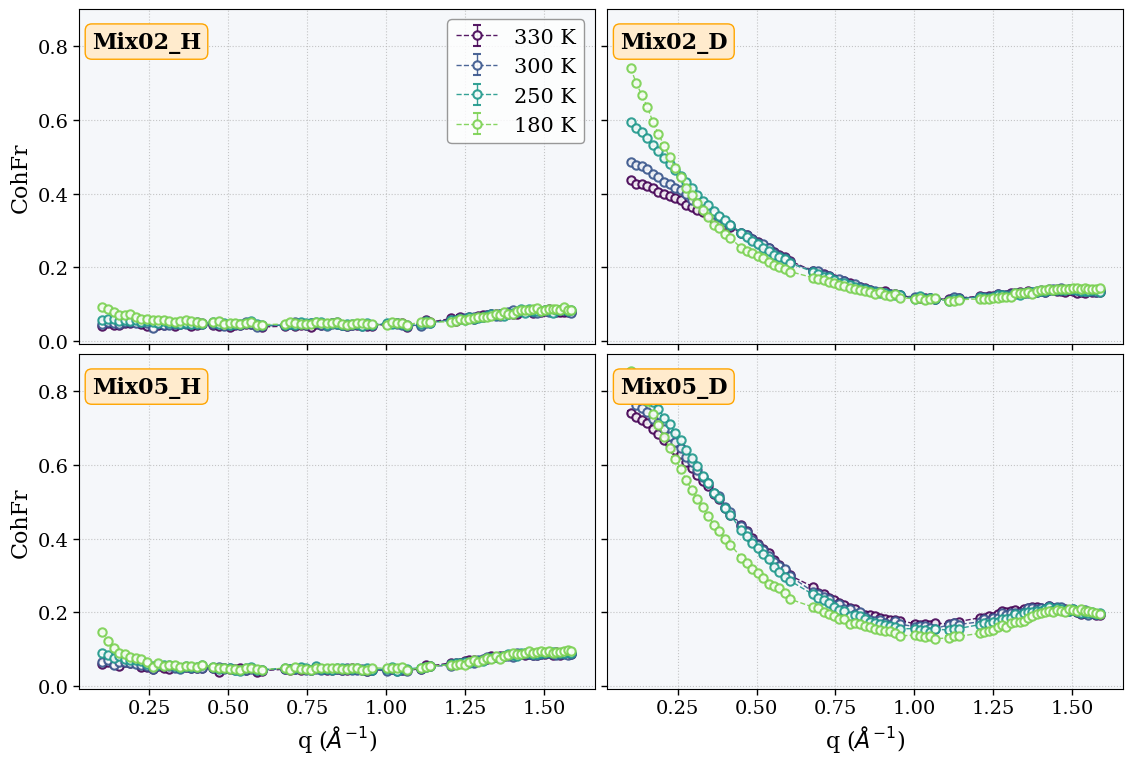

In [10]:
# ==================================================

# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams

# ==================================================
#  PLOT STYLE 
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)

# ==================================================

# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures2.pdf'


COLUMN_NAMES = [
    "qval", "up", "upErr", "down", "downErr", "average", "averageErr", 
    "pol", "polErr", "coh", "cohErr", "incoh", "incohErr", "CohFr", "CohFrErr"
]

samples = {
    "Mix02_H": [12420162, 12420163, 12420165, 12420168],
    "Mix02_D": [12420153, 12420154, 12420156, 12420159],
    "Mix05_H": [12420144, 12420145, 12420147, 12420150],
    "Mix05_D": [12420134, 12420136, 12420138, 12420141],
}

titles = ['Mix02_H', 'Mix02_D', 'Mix05_H', 'Mix05_D']
Temp = [330, 300, 250, 180]
skip1 = [12420135, 12420152, 12420155]

def load_diel(path, i):
    file = f"MD_DIF_{i}.txt"
    file_path = os.path.join(path, file)
    
    
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=1, comment='T', names=COLUMN_NAMES, header=None)
    return df, i

# ==================================================

# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes_flat = axes.flatten()
fig.subplots_adjust(left=0.08, right=0.95, bottom=0.10, top=0.95, hspace=0.03, wspace=0.024)

# ==================================================

# ==================================================
color_palette = plt.cm.viridis(np.linspace(0, 0.8, len(Temp)))

for ax_idx, (sample_name, ids) in enumerate(samples.items()):
    ax = axes_flat[ax_idx]
    ax.set_facecolor('#F5F7FA')
    
    
    for i, file_id in enumerate(ids):
        if file_id in skip1:
            continue
            
        try:
            df, f_num = load_diel(path, file_id)
            
            
            q = pd.to_numeric(df["qval"], errors='coerce')
            coh = pd.to_numeric(df["CohFr"], errors='coerce')     
            cohErr = pd.to_numeric(df["CohFrErr"], errors='coerce') 
            
           
            valid = q.notna() & coh.notna() & cohErr.notna()
            
            ax.errorbar(
                q[valid], coh[valid], yerr=cohErr[valid], 
                fmt='o', 
                markersize=6,
                markerfacecolor='white',
                markeredgewidth=1.5,
                color=color_palette[i], 
                label=f'{Temp[i]} K', 
                capsize=3, 
                linestyle='--', 
                linewidth=1,
                alpha=0.9
            )
        except Exception as e:
            print(f"Error loading ID {file_id}: {e}")

   
    if ax_idx % 2 == 0:
        ax.set_ylabel(r'CohFr', fontsize=16)
    if ax_idx >= 2:
        ax.set_xlabel(r'q ($\AA^{-1}$)', fontsize=16)
    
  
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.tick_params(direction='out', labelsize=14, width=1, size=4)

    
    if ax_idx == 0:
        ax.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=15, loc='upper right', ncol=1)
    
   
    ax.text(0.025, 0.87, titles[ax_idx], 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='bottom', 
            bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))


os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')

print(f'✅ All mixtures saved to: {output_pdf_path}')
plt.show()

✅ All mixtures saved to: /home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures.pdf


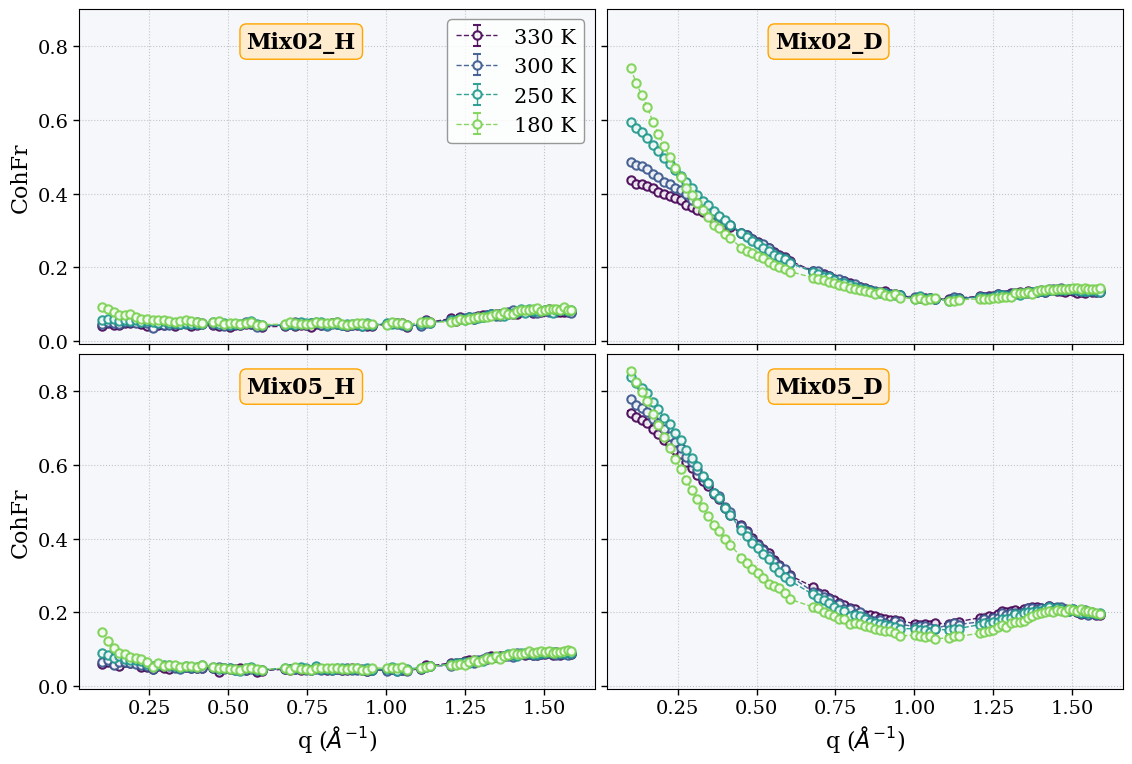

In [12]:

# ==================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams

# ===================================
# ==================================================
plt.style.use('seaborn-v0_8-muted')

PLOT_STYLE = {
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'figure.figsize': (12, 8),
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.7,
    'legend.fontsize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
}
rcParams.update(PLOT_STYLE)

# ==================================================

# ==================================================
path = "/home/tiwari/Desktop/PHD_ILL_RUC/WASP/Export 6-02-662/Export 6-02-662/"
output_pdf_path = '/home/tiwari/Desktop/PHD_ILL_RUC/Writing/Thesis_Anand/figure/mixture/Coh_Fraction_All_Mixtures.pdf'


COLUMN_NAMES = [
    "qval", "up", "upErr", "down", "downErr", "average", "averageErr", 
    "pol", "polErr", "coh", "cohErr", "incoh", "incohErr", "CohFr", "CohFrErr"
]

samples = {
    "Mix02_H": [12420162, 12420163, 12420165, 12420168],
    "Mix02_D": [12420153, 12420154, 12420156, 12420159],
    "Mix05_H": [12420144, 12420145, 12420147, 12420150],
    "Mix05_D": [12420134, 12420136, 12420138, 12420141],
}

titles = ['Mix02_H', 'Mix02_D', 'Mix05_H', 'Mix05_D']
Temp = [330, 300, 250, 180]
skip1 = [12420135, 12420152, 12420155]

def load_diel(path, i):
    file = f"MD_DIF_{i}.txt"
    file_path = os.path.join(path, file)
    
    
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=1, comment='T', names=COLUMN_NAMES, header=None)
    return df, i


# ==================================================
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes_flat = axes.flatten()
fig.subplots_adjust(left=0.08, right=0.95, bottom=0.10, top=0.95, hspace=0.03, wspace=0.024)


# ==================================================
color_palette = plt.cm.viridis(np.linspace(0, 0.8, len(Temp)))

for ax_idx, (sample_name, ids) in enumerate(samples.items()):
    ax = axes_flat[ax_idx]
    ax.set_facecolor('#F5F7FA')
    
    
    for i, file_id in enumerate(ids):
        if file_id in skip1:
            continue
            
        try:
            df, f_num = load_diel(path, file_id)
            
            
            q = pd.to_numeric(df["qval"], errors='coerce')
            coh = pd.to_numeric(df["CohFr"], errors='coerce')     # Directly selected name
            cohErr = pd.to_numeric(df["CohFrErr"], errors='coerce') # Directly selected name
            
            
            valid = q.notna() & coh.notna() & cohErr.notna()
            
            ax.errorbar(
                q[valid], coh[valid], yerr=cohErr[valid], 
                fmt='o', 
                markersize=6,
                markerfacecolor='white',
                markeredgewidth=1.5,
                color=color_palette[i], 
                label=f'{Temp[i]} K', 
                capsize=3, 
                linestyle='--', 
                linewidth=1,
                alpha=0.9
            )
        except Exception as e:
            print(f"Error loading ID {file_id}: {e}")

   
    if ax_idx % 2 == 0:
        ax.set_ylabel(r'CohFr', fontsize=16)
    if ax_idx >= 2:
        ax.set_xlabel(r'q ($\AA^{-1}$)', fontsize=16)
    
 
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.tick_params(direction='out', labelsize=14, width=1, size=4)

   
    if ax_idx == 0:
        ax.legend(frameon=True, facecolor="white", edgecolor='gray', fontsize=15, loc='upper right', ncol=1)
    
  
    ax.text(0.325, 0.87, titles[ax_idx], 
            transform=ax.transAxes, 
            fontsize=16, 
            fontweight='bold', 
            va='bottom', 
            bbox=dict(boxstyle='round', fc='blanchedalmond', ec='orange'))

# ==================================================

# ==================================================
os.makedirs(os.path.dirname(output_pdf_path), exist_ok=True)

with PdfPages(output_pdf_path) as pdf:
    pdf.savefig(fig, bbox_inches='tight')

print(f'✅ All mixtures saved to: {output_pdf_path}')
plt.show()